# 5293 Final Project
# Improving Faithfulness in RAG: Retrieval, Reranking, and Prompting Strategies

## Project Overview

Large language models can generate fluent answers, but they may still produce information that is not supported by evidence. Retrieval-Augmented Generation (RAG) is commonly used to reduce this problem by retrieving relevant passages and giving them to the model as context before answer generation. However, the final answer quality still depends on several design choices, including how passages are retrieved, whether they are reranked, and how the prompt instructs the model to use the evidence.

This project builds a simple RAG-based question answering system and compares different retrieval, reranking, and prompting strategies. The goal is not to train a new language model, but to evaluate how practical RAG design choices affect retrieval quality, answer quality, and faithfulness.

The main research questions are:

1. Does the retrieval method affect whether the system finds answer-supporting evidence?
2. Does cross-encoder reranking improve the quality of retrieved passages?
3. Do grounded prompting strategies make generated answers more faithful to the retrieved context?
4. Which combination of retrieval, reranking, and prompting works best in this simple RAG pipeline?

The project evaluates the system using both automatic and manual methods. Retrieval quality is measured using Recall@5. Answer quality is measured using Exact Match and token-level F1. Since these automatic metrics do not directly measure whether an answer is supported by evidence, we also include a small manual faithfulness review.

The final pipeline includes:

- BM25 sparse retrieval
- Dense retrieval using sentence embeddings
- Hybrid retrieval
- Cross-encoder reranking
- Standard, grounded, and evidence-based prompts
- Answer generation with a lightweight instruction-tuned model
- Automatic evaluation and manual faithfulness analysis
- A small interactive demo

## Setup

In [1]:
%%capture
!pip install -q datasets sentence-transformers rank-bm25 faiss-cpu evaluate rouge-score transformers accelerate

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm

from datasets import load_dataset
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder
import faiss

import re
from collections import Counter

## 1. Dataset Loading

We use a subset of the SQuAD validation set as the document-based question answering dataset. Each example contains a question, a reference context, and a ground-truth answer. For this project, the contexts are treated as the document collection for retrieval. The goal is to compare how different retrieval, reranking, and prompting strategies affect answer quality and faithfulness in a simple RAG pipeline.

In [3]:
raw_dataset = load_dataset("squad", split="validation")
dataset = raw_dataset.shuffle(seed=42).select(range(2000))

df = pd.DataFrame({
    "question": dataset["question"],
    "context": dataset["context"],
    "answer": [a["text"][0] if len(a["text"]) > 0 else "" for a in dataset["answers"]]
})

print("Number of QA pairs:", len(df))
print("Number of unique contexts:", df["context"].nunique())

df.head()

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

Number of QA pairs: 2000
Number of unique contexts: 1301


,question,context,answer
0,In what year did Massachusetts first require c...,Private schooling in the United States has bee...,1852
1,When were stromules discovered?,The chloroplast membranes sometimes protrude o...,1962
2,Which artist who had a major influence on the ...,Not only the work of British artists and craft...,Horace Walpole
3,"In 1890, who did the university decide to team...","In the 1890s, the University of Chicago, fearf...",several regional colleges and universities
4,Who got a touchdown making the score 10-7?,"After a punt from both teams, Carolina got on ...",Jonathan Stewart


In [4]:
N_RETRIEVAL_EVAL = 2000
N_RERANK_EVAL = 1000
N_GENERATION_EVAL = 200

In [5]:
print("Number of QA pairs:", len(df))
print("Number of unique contexts:", df["context"].nunique())

df[["question", "answer"]].sample(10, random_state=42)

Number of QA pairs: 2000
Number of unique contexts: 1301


,question,answer
1860,What is the weight of a bushel of coal in pounds?,94
353,What device is used to test the magnetic attra...,powerful magnet
1333,Whose relics reside in the Becket Casket?,St Thomas Becket
905,What do the owners of more capital end up having?,more wealth
1289,How many seats must a political party have to ...,five
1273,Who elects the members of the European Parliam...,citizens
938,How can function problems typically be restated?,decision problems
1731,What is the name of one type of computing meth...,distributed computing
65,"In Nepalese private schools, what is the prima...",English
1323,What are plants with plastid gene transformati...,transplastomic


## 2. Document Chunking

To build the retrieval corpus, we split each context passage into smaller text chunks. The document collection is built from a shuffled subset of 2,000 SQuAD validation examples. Chunking makes the setup closer to a standard RAG pipeline, where the retriever searches over shorter passages instead of full documents. We use a simple word-based chunking strategy with overlap so that information near chunk boundaries is less likely to be lost.

In [6]:
def chunk_text(text, chunk_size=120, overlap=30):
    words = text.split()
    chunks = []

    step = chunk_size - overlap
    for i in range(0, len(words), step):
        chunk = " ".join(words[i:i + chunk_size])
        if len(chunk.strip()) > 0:
            chunks.append(chunk)

    return chunks

In [7]:
documents = list(df["context"].drop_duplicates())

chunks = []

for doc_id, doc in enumerate(documents):
    doc_chunks = chunk_text(doc, chunk_size=120, overlap=30)

    for chunk_id, chunk in enumerate(doc_chunks):
        chunks.append({
            "doc_id": doc_id,
            "chunk_id": chunk_id,
            "text": chunk
        })

chunks_df = pd.DataFrame(chunks)

print("Number of original documents:", len(documents))
print("Number of chunks:", len(chunks_df))

chunks_df.head()

Number of original documents: 1301
Number of chunks: 2470


,doc_id,chunk_id,text
0,0,0,Private schooling in the United States has bee...
1,1,0,The chloroplast membranes sometimes protrude o...
2,1,1,"However, there is a growing body of evidence t..."
3,2,0,Not only the work of British artists and craft...
4,2,1,"from their collections, these include: Horace ..."


## 3. BM25 Retrieval Baseline

The first retrieval method is BM25, a sparse keyword-based retrieval algorithm. BM25 is a strong and simple baseline because it ranks passages based on lexical overlap between the query and the document chunks. In this project, BM25 serves as the baseline retrieval method before comparing it with dense embedding-based retrieval and hybrid retrieval.

In [8]:
tokenized_corpus = [text.lower().split() for text in chunks_df["text"]]

bm25 = BM25Okapi(tokenized_corpus)

In [9]:
def retrieve_bm25(query, top_k=5):
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)

    top_indices = np.argsort(scores)[::-1][:top_k]

    results = chunks_df.iloc[top_indices].copy()
    results["score"] = scores[top_indices]

    return results

In [10]:
sample_question = df["question"].iloc[0]
sample_answer = df["answer"].iloc[0]

print("Question:", sample_question)
print("Gold answer:", sample_answer)

bm25_results = retrieve_bm25(sample_question, top_k=5)
bm25_results

Question: In what year did Massachusetts first require children to be educated in schools?
Gold answer: 1852


,doc_id,chunk_id,text,score
2048,1069,0,There are many similarities and differences am...,21.016029
870,457,0,Most early Greeks did not even consider 1 to b...,17.824764
130,68,0,"Some Huguenots settled in Bedfordshire, one of...",15.688784
2019,1056,1,the system. Proposed routes include to Newcast...,15.469544
1956,1022,0,Although it is generally accepted that EU law ...,15.070261


### Initial BM25 Check

The BM25 retriever returns the top-ranked chunks based on keyword overlap with the question. This initial check helps verify that the retrieval function works correctly and that the returned passages are reasonable candidates for answer generation.

In [11]:
for i, row in bm25_results.iterrows():
    print("=" * 80)
    print("Score:", row["score"])
    print(row["text"][:800])

Score: 21.016029077207595
There are many similarities and differences among teachers around the world. In almost all countries teachers are educated in a university or college. Governments may require certification by a recognized body before they can teach in a school. In many countries, elementary school education certificate is earned after completion of high school. The high school student follows an education specialty track, obtain the prerequisite "student-teaching" time, and receive a special diploma to begin teaching after graduation. In addition to certification, many educational institutions especially within the US, require that prospective teachers pass a background check and psychiatric evaluation to be able to teach in classroom. This is not always the case with adult further learning institutions bu
Score: 17.824763692490084
Most early Greeks did not even consider 1 to be a number, so they could not consider it to be a prime. By the Middle Ages and Renaissance many math

## 4. Retrieval Evaluation

Before evaluating generated answers, we first evaluate whether the retriever can find passages that contain the gold answer. Since SQuAD provides a reference answer for each question, we use a simple Recall@5-style metric: a retrieval is counted as successful if the gold answer appears in at least one of the top five retrieved chunks.

This is not a perfect retrieval metric because it only checks exact answer string overlap, but it is useful as a simple and interpretable baseline for comparing retrieval methods. In this experiment, first-stage retrieval methods are evaluated on all 2,000 questions in the shuffled SQuAD subset.

In [12]:
def normalize_text(s):
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9\s]", "", s)
    s = " ".join(s.split())
    return s


def answer_in_context(gold_answer, context):
    gold_answer = normalize_text(gold_answer)
    context = normalize_text(context)

    if len(gold_answer) == 0:
        return False

    return gold_answer in context


def retrieval_hit(gold_answer, retrieved_contexts):
    return int(any(answer_in_context(gold_answer, c) for c in retrieved_contexts))

In [13]:
def evaluate_bm25_retrieval(df, top_k=5, n_eval=100):
    eval_df = df.iloc[:min(n_eval, len(df))].copy()
    hits = []

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
        question = row["question"]
        gold_answer = row["answer"]

        retrieved = retrieve_bm25(question, top_k=top_k)
        retrieved_contexts = retrieved["text"].tolist()

        hit = retrieval_hit(gold_answer, retrieved_contexts)
        hits.append(hit)

    recall_at_k = np.mean(hits)

    return recall_at_k

In [14]:
bm25_recall_at_5 = evaluate_bm25_retrieval(
    df,
    top_k=5,
    n_eval=N_RETRIEVAL_EVAL
)

print("BM25 Recall@5:", bm25_recall_at_5)

100%|██████████| 2000/2000 [00:14<00:00, 134.81it/s]

BM25 Recall@5: 0.79


### BM25 Retrieval Result

For the shuffled SQuAD subset, BM25 was evaluated on **2,000** questions and achieved a Recall@5 of **0.790**. This means that in approximately **79.0%** of evaluated questions, at least one of the top five retrieved chunks contained the gold answer string.

This result provides the baseline retrieval performance for the RAG system. Later experiments with dense retrieval, hybrid retrieval, and reranking will be compared against this BM25 baseline.

## 5. Dense Retrieval

The second retrieval method is dense retrieval using sentence embeddings. Unlike BM25, which relies on lexical overlap, dense retrieval maps both questions and document chunks into a continuous embedding space. This allows the retriever to find passages that are semantically related to the query even when they do not share the exact same words.

We use a pretrained SentenceTransformer model to encode all chunks from the shuffled 2,000-example SQuAD subset, and FAISS is used for efficient nearest-neighbor search.

In [15]:
embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [16]:
chunk_embeddings = embed_model.encode(
    chunks_df["text"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embedding shape:", chunk_embeddings.shape)

Batches:   0%|          | 0/78 [00:00<?, ?it/s]

Embedding shape: (2470, 384)


In [17]:
dimension = chunk_embeddings.shape[1]

dense_index = faiss.IndexFlatIP(dimension)
dense_index.add(chunk_embeddings)

print("Number of vectors in FAISS index:", dense_index.ntotal)

Number of vectors in FAISS index: 2470


In [18]:
def retrieve_dense(query, top_k=5):
    query_embedding = embed_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    scores, indices = dense_index.search(query_embedding, top_k)

    results = chunks_df.iloc[indices[0]].copy()
    results["score"] = scores[0]

    return results

In [19]:
dense_results = retrieve_dense(sample_question, top_k=5)

print("Question:", sample_question)
print("Gold answer:", sample_answer)

dense_results

Question: In what year did Massachusetts first require children to be educated in schools?
Gold answer: 1852


,doc_id,chunk_id,text,score
0,0,0,Private schooling in the United States has bee...,0.632354
1097,575,1,of university. All schools had a common curric...,0.503367
2196,1151,0,In the early years the College trained many Pu...,0.490934
925,489,0,During the mass high school education movement...,0.477054
2206,1156,1,"that from 2008, secondary education would be h...",0.442598


In [20]:
for i, row in dense_results.iterrows():
    print("=" * 80)
    print("Score:", row["score"])
    print(row["text"][:800])

Score: 0.6323538422584534
Private schooling in the United States has been debated by educators, lawmakers and parents, since the beginnings of compulsory education in Massachusetts in 1852. The Supreme Court precedent appears to favor educational choice, so long as states may set standards for educational accomplishment. Some of the most relevant Supreme Court case law on this is as follows: Runyon v. McCrary, 427 U.S. 160 (1976); Wisconsin v. Yoder, 406 U.S. 205 (1972); Pierce v. Society of Sisters, 268 U.S. 510 (1925); Meyer v. Nebraska, 262 U.S. 390 (1923).
Score: 0.5033669471740723
of university. All schools had a common curriculum.
Score: 0.4909343123435974
In the early years the College trained many Puritan ministers.[citation needed] (A 1643 publication said the school's purpose was "to advance learning and perpetuate it to posterity, dreading to leave an illiterate ministry to the churches when our present ministers shall lie in the dust".) It offered a classic curriculum on th

## 6. Dense Retrieval Evaluation

After building the dense retrieval index, we evaluate it using the same Recall@5 metric used for BM25. This allows a direct comparison between sparse keyword-based retrieval and dense semantic retrieval under the same dataset and evaluation setup.

Dense retrieval is evaluated on all 2,000 questions from the shuffled SQuAD subset.

In [21]:
def evaluate_dense_retrieval(df, top_k=5, n_eval=100):
    eval_df = df.iloc[:min(n_eval, len(df))].copy()
    hits = []

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
        question = row["question"]
        gold_answer = row["answer"]

        retrieved = retrieve_dense(question, top_k=top_k)
        retrieved_contexts = retrieved["text"].tolist()

        hit = retrieval_hit(gold_answer, retrieved_contexts)
        hits.append(hit)

    recall_at_k = np.mean(hits)

    return recall_at_k

In [22]:
dense_recall_at_5 = evaluate_dense_retrieval(
    df,
    top_k=5,
    n_eval=N_RETRIEVAL_EVAL
)

print("Dense Recall@5:", dense_recall_at_5)

100%|██████████| 2000/2000 [00:14<00:00, 134.90it/s]

Dense Recall@5: 0.8685


In [23]:
retrieval_summary = pd.DataFrame({
    "Method": ["BM25", "Dense Retrieval"],
    "Recall@5": [bm25_recall_at_5, dense_recall_at_5]
})

retrieval_summary

,Method,Recall@5
0,BM25,0.7900
1,Dense Retrieval,0.8685


### BM25 vs. Dense Retrieval

BM25 achieved a Recall@5 of **0.7900**, while dense retrieval achieved a Recall@5 of **0.8685** on the first 100 validation examples.

This comparison shows whether semantic embedding-based retrieval improves over the sparse keyword baseline. BM25 can perform well when the question and answer context share similar wording, while dense retrieval may help when the relevant passage is semantically related but uses different words.

## 7. Hybrid Retrieval

The third retrieval method is hybrid retrieval, which combines sparse BM25 retrieval and dense embedding-based retrieval. BM25 is useful for exact keyword matching, while dense retrieval can capture semantic similarity. By combining both candidate sets, hybrid retrieval may improve robustness because it can retrieve passages that are relevant either lexically or semantically.

In this implementation, we retrieve a larger candidate pool from both BM25 and dense retrieval, merge the results, remove duplicate chunks, and rank candidates using a simple reciprocal-rank style score. This avoids giving priority only to whichever retriever appears first in the concatenated results.

In [24]:
def retrieve_hybrid(query, top_k=5, pool_k=10):
    bm25_results = retrieve_bm25(query, top_k=pool_k).copy()
    dense_results = retrieve_dense(query, top_k=pool_k).copy()

    bm25_results["source"] = "bm25"
    dense_results["source"] = "dense"

    bm25_results["rank"] = np.arange(1, len(bm25_results) + 1)
    dense_results["rank"] = np.arange(1, len(dense_results) + 1)

    bm25_results["hybrid_score"] = 1 / bm25_results["rank"]
    dense_results["hybrid_score"] = 1 / dense_results["rank"]

    combined = pd.concat([bm25_results, dense_results], axis=0)

    combined = (
        combined
        .groupby(["doc_id", "chunk_id"], as_index=False)
        .agg({
            "text": "first",
            "score": "max",
            "source": lambda x: "+".join(sorted(set(x))),
            "rank": "min",
            "hybrid_score": "sum"
        })
    )

    combined = combined.sort_values("hybrid_score", ascending=False)

    return combined.head(top_k)

In [25]:
hybrid_results = retrieve_hybrid(sample_question, top_k=5, pool_k=10)

print("Question:", sample_question)
print("Gold answer:", sample_answer)

hybrid_results

Question: In what year did Massachusetts first require children to be educated in schools?
Gold answer: 1852


,doc_id,chunk_id,text,score,source,rank,hybrid_score
0,0,0,Private schooling in the United States has bee...,0.632354,dense,1,1.000000
14,1069,0,There are many similarities and differences am...,21.016029,bm25,1,1.000000
4,457,0,Most early Greeks did not even consider 1 to b...,17.824764,bm25,2,0.500000
6,575,1,of university. All schools had a common curric...,0.503367,dense,2,0.500000
1,68,0,"Some Huguenots settled in Bedfordshire, one of...",15.688784,bm25,3,0.333333


In [26]:
for i, row in hybrid_results.iterrows():
    print("=" * 80)
    print("Source:", row["source"])
    print("Hybrid score:", row["hybrid_score"])
    print(row["text"][:800])

Source: dense
Hybrid score: 1.0
Private schooling in the United States has been debated by educators, lawmakers and parents, since the beginnings of compulsory education in Massachusetts in 1852. The Supreme Court precedent appears to favor educational choice, so long as states may set standards for educational accomplishment. Some of the most relevant Supreme Court case law on this is as follows: Runyon v. McCrary, 427 U.S. 160 (1976); Wisconsin v. Yoder, 406 U.S. 205 (1972); Pierce v. Society of Sisters, 268 U.S. 510 (1925); Meyer v. Nebraska, 262 U.S. 390 (1923).
Source: bm25
Hybrid score: 1.0
There are many similarities and differences among teachers around the world. In almost all countries teachers are educated in a university or college. Governments may require certification by a recognized body before they can teach in a school. In many countries, elementary school education certificate is earned after completion of high school. The high school student follows an education spec

## 8. Hybrid Retrieval Evaluation

We evaluate hybrid retrieval using the same Recall@5 metric. Since hybrid retrieval combines BM25 and dense retrieval candidates, the goal is to test whether combining lexical and semantic search improves the chance of retrieving a passage that contains the gold answer.

Hybrid retrieval is evaluated on all 2,000 questions from the shuffled SQuAD subset.

In [27]:
def evaluate_hybrid_retrieval(df, top_k=5, n_eval=100):
    eval_df = df.iloc[:min(n_eval, len(df))].copy()
    hits = []

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
        question = row["question"]
        gold_answer = row["answer"]

        retrieved = retrieve_hybrid(question, top_k=top_k, pool_k=10)
        retrieved_contexts = retrieved["text"].tolist()

        hit = retrieval_hit(gold_answer, retrieved_contexts)
        hits.append(hit)

    recall_at_k = np.mean(hits)

    return recall_at_k

In [28]:
hybrid_recall_at_5 = evaluate_hybrid_retrieval(
    df,
    top_k=5,
    n_eval=N_RETRIEVAL_EVAL
)

print("Hybrid Recall@5:", hybrid_recall_at_5)

100%|██████████| 2000/2000 [00:42<00:00, 46.81it/s]

Hybrid Recall@5: 0.9125


In [29]:
retrieval_summary = pd.DataFrame({
    "Method": ["BM25", "Dense Retrieval", "Hybrid Retrieval"],
    "Recall@5": [bm25_recall_at_5, dense_recall_at_5, hybrid_recall_at_5]
})

retrieval_summary

,Method,Recall@5
0,BM25,0.7900
1,Dense Retrieval,0.8685
2,Hybrid Retrieval,0.9125


### Retrieval Method Comparison

The first-stage retrieval results show that BM25 achieved a Recall@5 of **0.7900**, dense retrieval achieved a Recall@5 of **0.8685**, and hybrid retrieval achieved a Recall@5 of **0.9125** on all **2,000** questions from the shuffled SQuAD subset.

These results suggest that retrieval method choice has a clear effect on whether the RAG system can access answer-supporting evidence. Since answer generation depends heavily on the retrieved context, stronger retrieval performance is expected to improve downstream answer quality and faithfulness.

## 9. Reranking

After retrieval, we add a reranking step to improve the ordering of retrieved passages. The first-stage retriever returns a candidate pool, but the top-ranked passages may not always be the most relevant ones. A cross-encoder reranker scores each question-passage pair jointly, which usually gives a more accurate relevance score than using BM25 scores or embedding similarity alone.

In this project, reranking is applied after first-stage retrieval. We first retrieve a larger candidate pool, then use the reranker to select the final top five passages. Since reranking requires scoring each query-passage pair with a transformer model, it is more computationally expensive than first-stage retrieval.

In [30]:
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [31]:
def rerank_results(query, retrieved_df, top_k=5):
    if len(retrieved_df) == 0:
        return retrieved_df

    pairs = [(query, text) for text in retrieved_df["text"].tolist()]
    scores = reranker.predict(pairs)

    reranked = retrieved_df.copy()
    reranked["rerank_score"] = scores
    reranked = reranked.sort_values("rerank_score", ascending=False)

    return reranked.head(top_k)

## 10. Reranked Retrieval Evaluation

We evaluate whether reranking improves retrieval quality by applying the cross-encoder reranker to candidate pools from BM25, dense retrieval, and hybrid retrieval. For each method, the retriever first returns a larger candidate set, and the reranker then selects the final top five passages.

Because reranking is more computationally expensive than first-stage retrieval, reranked retrieval is evaluated on a subset of the questions rather than the full 2,000-question evaluation set.

In [32]:
def retrieve_bm25_reranked(query, top_k=5, pool_k=20):
    candidates = retrieve_bm25(query, top_k=pool_k).copy()
    candidates["source"] = "bm25"
    return rerank_results(query, candidates, top_k=top_k)


def retrieve_dense_reranked(query, top_k=5, pool_k=20):
    candidates = retrieve_dense(query, top_k=pool_k).copy()
    candidates["source"] = "dense"
    return rerank_results(query, candidates, top_k=top_k)


def retrieve_hybrid_reranked(query, top_k=5, pool_k=20):
    bm25_candidates = retrieve_bm25(query, top_k=pool_k).copy()
    dense_candidates = retrieve_dense(query, top_k=pool_k).copy()

    bm25_candidates["source"] = "bm25"
    dense_candidates["source"] = "dense"

    bm25_candidates["rank"] = np.arange(1, len(bm25_candidates) + 1)
    dense_candidates["rank"] = np.arange(1, len(dense_candidates) + 1)

    bm25_candidates["hybrid_score"] = 1 / bm25_candidates["rank"]
    dense_candidates["hybrid_score"] = 1 / dense_candidates["rank"]

    candidates = pd.concat([bm25_candidates, dense_candidates], axis=0)

    candidates = (
        candidates
        .groupby(["doc_id", "chunk_id"], as_index=False)
        .agg({
            "text": "first",
            "score": "max",
            "source": lambda x: "+".join(sorted(set(x))),
            "rank": "min",
            "hybrid_score": "sum"
        })
    )

    candidates = candidates.sort_values("hybrid_score", ascending=False)

    return rerank_results(query, candidates, top_k=top_k)

In [33]:
hybrid_reranked_results = retrieve_hybrid_reranked(sample_question, top_k=5, pool_k=20)

print("Question:", sample_question)
print("Gold answer:", sample_answer)

hybrid_reranked_results

Question: In what year did Massachusetts first require children to be educated in schools?
Gold answer: 1852


,doc_id,chunk_id,text,score,source,rank,hybrid_score,rerank_score
0,0,0,Private schooling in the United States has bee...,0.632354,dense,1,1.000000,3.817114
20,762,0,Harvard was formed in 1636 by vote of the Grea...,14.159738,bm25,18,0.055556,-4.093204
13,575,0,Kenya's first system of education was introduc...,0.376215,dense,13,0.076923,-4.709186
11,489,0,During the mass high school education movement...,0.477054,dense,4,0.250000,-4.785449
33,1156,1,"that from 2008, secondary education would be h...",0.442598,dense,5,0.200000,-6.430114


In [34]:
for i, row in hybrid_reranked_results.iterrows():
    print("=" * 80)
    print("Source:", row.get("source", "unknown"))
    print("Rerank score:", row.get("rerank_score", None))
    print("Hybrid score:", row.get("hybrid_score", None))
    print(row["text"][:800])

Source: dense
Rerank score: 3.8171141147613525
Hybrid score: 1.0
Private schooling in the United States has been debated by educators, lawmakers and parents, since the beginnings of compulsory education in Massachusetts in 1852. The Supreme Court precedent appears to favor educational choice, so long as states may set standards for educational accomplishment. Some of the most relevant Supreme Court case law on this is as follows: Runyon v. McCrary, 427 U.S. 160 (1976); Wisconsin v. Yoder, 406 U.S. 205 (1972); Pierce v. Society of Sisters, 268 U.S. 510 (1925); Meyer v. Nebraska, 262 U.S. 390 (1923).
Source: bm25
Rerank score: -4.093203544616699
Hybrid score: 0.05555555555555555
Harvard was formed in 1636 by vote of the Great and General Court of the Massachusetts Bay Colony. It was initially called "New College" or "the college at New Towne". In 1638, the college became home for North America's first known printing press, carried by the ship John of London. In 1639, the college was rena

## 11. Evaluate Reranked Retrieval

In [35]:
def evaluate_retrieval_function(retrieval_fn, df, top_k=5, n_eval=100):
    eval_df = df.iloc[:min(n_eval, len(df))].copy()
    hits = []

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
        question = row["question"]
        gold_answer = row["answer"]

        retrieved = retrieval_fn(question, top_k=top_k)
        retrieved_contexts = retrieved["text"].tolist()

        hit = retrieval_hit(gold_answer, retrieved_contexts)
        hits.append(hit)

    return np.mean(hits)

In [36]:
bm25_rerank_recall_at_5 = evaluate_retrieval_function(
    retrieve_bm25_reranked,
    df,
    top_k=5,
    n_eval=N_RERANK_EVAL
)

dense_rerank_recall_at_5 = evaluate_retrieval_function(
    retrieve_dense_reranked,
    df,
    top_k=5,
    n_eval=N_RERANK_EVAL
)

hybrid_rerank_recall_at_5 = evaluate_retrieval_function(
    retrieve_hybrid_reranked,
    df,
    top_k=5,
    n_eval=N_RERANK_EVAL
)

print("BM25 + Rerank Recall@5:", bm25_rerank_recall_at_5)
print("Dense + Rerank Recall@5:", dense_rerank_recall_at_5)
print("Hybrid + Rerank Recall@5:", hybrid_rerank_recall_at_5)

100%|██████████| 1000/1000 [00:59<00:00, 16.73it/s]

BM25 + Rerank Recall@5: 0.881
Dense + Rerank Recall@5: 0.937
Hybrid + Rerank Recall@5: 0.973


In [37]:
retrieval_summary = pd.DataFrame({
    "Method": [
        "BM25",
        "Dense Retrieval",
        "Hybrid Retrieval",
        "BM25 + Rerank",
        "Dense + Rerank",
        "Hybrid + Rerank"
    ],
    "Recall@5": [
        bm25_recall_at_5,
        dense_recall_at_5,
        hybrid_recall_at_5,
        bm25_rerank_recall_at_5,
        dense_rerank_recall_at_5,
        hybrid_rerank_recall_at_5
    ]
})

retrieval_summary

,Method,Recall@5
0,BM25,0.7900
1,Dense Retrieval,0.8685
2,Hybrid Retrieval,0.9125
3,BM25 + Rerank,0.8810
4,Dense + Rerank,0.9370
5,Hybrid + Rerank,0.9730


### Reranking Result

After adding the cross-encoder reranker, BM25 + reranking achieved a Recall@5 of **0.8810**, dense retrieval + reranking achieved a Recall@5 of **0.9370**, and hybrid retrieval + reranking achieved a Recall@5 of **0.9730** on **1,000** evaluated questions.

Compared with the first-stage retrieval results, reranking improved dense retrieval from **0.8685** to **0.9370** and hybrid retrieval from **0.9125** to **0.9730**. BM25 + reranking achieved **0.8810**, which is higher than the BM25 first-stage result of **0.7900**, but the improvement was smaller than for the dense and hybrid settings.

Overall, **Hybrid + Rerank** achieved the strongest retrieval performance, with a Recall@5 of **0.9730**. This supports the idea that combining sparse and dense retrieval creates a stronger candidate pool, while cross-encoder reranking improves the final ordering of retrieved passages.

## 12. Prompting Strategies

After retrieving relevant passages, the next step is answer generation. Since the project studies faithfulness in RAG, we compare different prompting strategies to see whether stricter instructions help the model stay closer to the retrieved evidence.

We use three prompt types:

1. **Standard prompt**: asks the model to answer using the retrieved context.
2. **Grounded prompt**: explicitly tells the model to answer only from the provided context and say "Not enough information" if the answer is unsupported.
3. **Evidence prompt**: asks the model to answer and identify which passage supports the answer.

These prompts allow us to evaluate whether prompt design affects answer quality and faithfulness after retrieval.

In [38]:
def build_standard_prompt(question, contexts):
    context_text = "\n\n".join(contexts)

    return f"""
Answer the question using the following context.

Context:
{context_text}

Question:
{question}

Answer:
"""


def build_grounded_prompt(question, contexts):
    context_text = "\n\n".join(contexts)

    return f"""
You must answer the question only using the provided context.
If the answer is not supported by the context, say "Not enough information."

Context:
{context_text}

Question:
{question}

Grounded answer:
"""


def build_evidence_prompt(question, contexts):
    context_text = "\n\n".join(
        [f"[Passage {i+1}] {context}" for i, context in enumerate(contexts)]
    )

    return f"""
Answer the question using only the passages below.
After the answer, briefly mention which passage supports it.

Passages:
{context_text}

Question:
{question}

Answer:
Evidence:
"""


def build_short_grounded_prompt(question, contexts):
    context_text = "\n\n".join(contexts)

    return f"""
Answer the question using only the provided context.
Return only the shortest possible answer span.
Do not explain.
If the answer is not in the context, say "Not enough information."

Context:
{context_text}

Question:
{question}

Short answer:
"""


In [39]:
test_contexts = hybrid_reranked_results["text"].tolist()

print(build_grounded_prompt(sample_question, test_contexts)[:2000])


You must answer the question only using the provided context.
If the answer is not supported by the context, say "Not enough information."

Context:
Private schooling in the United States has been debated by educators, lawmakers and parents, since the beginnings of compulsory education in Massachusetts in 1852. The Supreme Court precedent appears to favor educational choice, so long as states may set standards for educational accomplishment. Some of the most relevant Supreme Court case law on this is as follows: Runyon v. McCrary, 427 U.S. 160 (1976); Wisconsin v. Yoder, 406 U.S. 205 (1972); Pierce v. Society of Sisters, 268 U.S. 510 (1925); Meyer v. Nebraska, 262 U.S. 390 (1923).

Harvard was formed in 1636 by vote of the Great and General Court of the Massachusetts Bay Colony. It was initially called "New College" or "the college at New Towne". In 1638, the college became home for North America's first known printing press, carried by the ship John of London. In 1639, the college wa

## 13. Answer Generation Model

For answer generation, we use `google/flan-t5-base`, a lightweight instruction-tuned sequence-to-sequence model. This model is small enough to run efficiently in Google Colab while still supporting instruction-style prompting.

Since this project focuses on comparing RAG design choices rather than training a new language model, using a pretrained generator keeps the scope manageable. In the later generation experiments, we evaluate answer quality on a subset of 200 questions because answer generation is more computationally expensive than retrieval.

In [40]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

generator_model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(generator_model_name)
generation_model = AutoModelForSeq2SeqLM.from_pretrained(generator_model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
generation_model = generation_model.to(device)

print("Using device:", device)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Using device: cuda


In [41]:
def generate_answer(prompt, max_new_tokens=128):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        outputs = generation_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return answer

In [42]:
sample_contexts = retrieve_hybrid_reranked(sample_question, top_k=5, pool_k=20)["text"].tolist()
sample_prompt = build_grounded_prompt(sample_question, sample_contexts)

sample_generated_answer = generate_answer(sample_prompt)

print("Question:", sample_question)
print("Gold answer:", sample_answer)
print("Generated answer:", sample_generated_answer)

Question: In what year did Massachusetts first require children to be educated in schools?
Gold answer: 1852
Generated answer: Not enough information.


## 14. Full RAG Pipeline

We now combine retrieval, optional reranking, prompting, and answer generation into a single RAG function. This function allows us to run controlled experiments across different retrieval methods, reranking settings, and prompt types.

The full pipeline follows this structure:

1. Retrieve candidate passages using BM25, dense retrieval, or hybrid retrieval.
2. Optionally apply cross-encoder reranking.
3. Build a prompt using the selected prompting strategy.
4. Generate an answer using the pretrained generation model.
5. Return the generated answer and retrieved evidence for evaluation.

In [43]:
def get_retrieved_contexts(question, retrieval_method="dense", use_rerank=True, top_k=5, pool_k=20):
    if retrieval_method == "bm25":
        if use_rerank:
            retrieved = retrieve_bm25_reranked(question, top_k=top_k, pool_k=pool_k)
        else:
            retrieved = retrieve_bm25(question, top_k=top_k)

    elif retrieval_method == "dense":
        if use_rerank:
            retrieved = retrieve_dense_reranked(question, top_k=top_k, pool_k=pool_k)
        else:
            retrieved = retrieve_dense(question, top_k=top_k)

    elif retrieval_method == "hybrid":
        if use_rerank:
            retrieved = retrieve_hybrid_reranked(question, top_k=top_k, pool_k=pool_k)
        else:
            retrieved = retrieve_hybrid(question, top_k=top_k, pool_k=pool_k)

    else:
        raise ValueError("Invalid retrieval method.")

    return retrieved


def build_prompt(question, contexts, prompt_type="grounded"):
    if prompt_type == "standard":
        return build_standard_prompt(question, contexts)
    elif prompt_type == "grounded":
        return build_grounded_prompt(question, contexts)
    elif prompt_type == "evidence":
        return build_evidence_prompt(question, contexts)
    elif prompt_type == "short_grounded":
        return build_short_grounded_prompt(question, contexts)
    else:
        raise ValueError("Invalid prompt type.")


def run_rag(question, retrieval_method="dense", use_rerank=True, prompt_type="grounded", top_k=5, pool_k=20):
    retrieved = get_retrieved_contexts(
        question=question,
        retrieval_method=retrieval_method,
        use_rerank=use_rerank,
        top_k=top_k,
        pool_k=pool_k
    )

    contexts = retrieved["text"].tolist()
    prompt = build_prompt(question, contexts, prompt_type=prompt_type)
    generated_answer = generate_answer(prompt)

    return {
        "question": question,
        "generated_answer": generated_answer,
        "retrieved_contexts": contexts,
        "retrieved_df": retrieved,
        "prompt": prompt
    }

In [44]:
test_output = run_rag(
    question=sample_question,
    retrieval_method="hybrid",
    use_rerank=True,
    prompt_type="grounded",
    top_k=5,
    pool_k=20
)

print("Question:", test_output["question"])
print("Gold answer:", sample_answer)
print("Generated answer:", test_output["generated_answer"])

Question: In what year did Massachusetts first require children to be educated in schools?
Gold answer: 1852
Generated answer: Not enough information.


## 15. Automatic Answer Evaluation

After building the full RAG pipeline, we evaluate generated answers using Exact Match and token-level F1. Exact Match measures whether the generated answer exactly matches the gold answer after normalization. F1 is more flexible because it measures word overlap between the generated answer and the gold answer.

These metrics are not perfect measures of faithfulness, but they provide a useful automatic measure of answer quality and allow us to compare different RAG configurations. Since answer generation is computationally more expensive than retrieval, answer quality is evaluated on a subset of 200 questions.

In [45]:
def exact_match_score(prediction, gold_answer):
    return int(normalize_text(prediction) == normalize_text(gold_answer))


def token_f1_score(prediction, gold_answer):
    pred_tokens = normalize_text(prediction).split()
    gold_tokens = normalize_text(gold_answer).split()

    if len(pred_tokens) == 0 and len(gold_tokens) == 0:
        return 1.0
    if len(pred_tokens) == 0 or len(gold_tokens) == 0:
        return 0.0

    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(gold_tokens)

    return 2 * precision * recall / (precision + recall)

## 16. RAG Experiment Setup

We compare several RAG configurations that vary by retrieval method, reranking, and prompt type. The selected configurations are designed to answer the main project questions: whether retrieval method matters, whether reranking improves performance, and whether prompting strategy affects answer quality.

In addition to the original standard, grounded, and evidence-based prompts, we also add a **short grounded prompt**. This prompt asks the generator to return only the shortest possible answer span, which is better aligned with SQuAD-style Exact Match and F1 evaluation.

Answer generation is evaluated on 200 questions across ten configurations, producing 2,000 generated answers in total.


In [46]:
experiment_configs = [
    {
        "config_name": "BM25 + Standard",
        "retrieval_method": "bm25",
        "use_rerank": False,
        "prompt_type": "standard"
    },
    {
        "config_name": "BM25 + Grounded",
        "retrieval_method": "bm25",
        "use_rerank": False,
        "prompt_type": "grounded"
    },
    {
        "config_name": "BM25 + Rerank + Grounded",
        "retrieval_method": "bm25",
        "use_rerank": True,
        "prompt_type": "grounded"
    },
    {
        "config_name": "Dense + Grounded",
        "retrieval_method": "dense",
        "use_rerank": False,
        "prompt_type": "grounded"
    },
    {
        "config_name": "Dense + Rerank + Grounded",
        "retrieval_method": "dense",
        "use_rerank": True,
        "prompt_type": "grounded"
    },
    {
        "config_name": "Hybrid + Rerank + Grounded",
        "retrieval_method": "hybrid",
        "use_rerank": True,
        "prompt_type": "grounded"
    },
    {
        "config_name": "Hybrid + Rerank + Evidence",
        "retrieval_method": "hybrid",
        "use_rerank": True,
        "prompt_type": "evidence"
    },
    {
        "config_name": "Dense + Short Grounded",
        "retrieval_method": "dense",
        "use_rerank": False,
        "prompt_type": "short_grounded"
    },
    {
        "config_name": "Dense + Rerank + Short Grounded",
        "retrieval_method": "dense",
        "use_rerank": True,
        "prompt_type": "short_grounded"
    },
    {
        "config_name": "Hybrid + Rerank + Short Grounded",
        "retrieval_method": "hybrid",
        "use_rerank": True,
        "prompt_type": "short_grounded"
    }
]


In [47]:
def run_experiments(df, configs, n_eval=50, top_k=5, pool_k=20):
    eval_df = df.iloc[:min(n_eval, len(df))].copy()
    all_results = []

    for config in configs:
        print("Running config:", config["config_name"])

        for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
            question = row["question"]
            gold_answer = row["answer"]

            rag_output = run_rag(
                question=question,
                retrieval_method=config["retrieval_method"],
                use_rerank=config["use_rerank"],
                prompt_type=config["prompt_type"],
                top_k=top_k,
                pool_k=pool_k
            )

            generated_answer = rag_output["generated_answer"]
            retrieved_contexts = rag_output["retrieved_contexts"]

            all_results.append({
                "config_name": config["config_name"],
                "retrieval_method": config["retrieval_method"],
                "use_rerank": config["use_rerank"],
                "prompt_type": config["prompt_type"],
                "question": question,
                "gold_answer": gold_answer,
                "generated_answer": generated_answer,
                "top_context": retrieved_contexts[0] if len(retrieved_contexts) > 0 else "",
                "em": exact_match_score(generated_answer, gold_answer),
                "f1": token_f1_score(generated_answer, gold_answer)
            })

    return pd.DataFrame(all_results)

In [48]:
rag_results_df = run_experiments(
    df=df,
    configs=experiment_configs,
    n_eval=N_GENERATION_EVAL,
    top_k=5,
    pool_k=20
)

rag_results_df.head()

Running config: BM25 + Standard


100%|██████████| 200/200 [00:50<00:00,  3.93it/s]


Running config: BM25 + Grounded


100%|██████████| 200/200 [00:34<00:00,  5.74it/s]


Running config: BM25 + Rerank + Grounded


...

Running config: Dense + Rerank + Short Grounded


100%|██████████| 200/200 [00:36<00:00,  5.51it/s]


Running config: Hybrid + Rerank + Short Grounded


100%|██████████| 200/200 [00:44<00:00,  4.53it/s]


,config_name,retrieval_method,use_rerank,prompt_type,question,gold_answer,generated_answer,top_context,em,f1
0,BM25 + Standard,bm25,False,standard,In what year did Massachusetts first require c...,1852,Huguenots settled in Bedfordshire,There are many similarities and differences am...,0,0.0
1,BM25 + Standard,bm25,False,standard,When were stromules discovered?,1962,France,The chloroplast membranes sometimes protrude o...,0,0.0
2,BM25 + Standard,bm25,False,standard,Which artist who had a major influence on the ...,Horace Walpole,Warsaw.,Not only the work of British artists and craft...,0,0.0
3,BM25 + Standard,bm25,False,standard,"In 1890, who did the university decide to team...",several regional colleges and universities,clinch the number one overall AFC seed,"in just 9 starts. Behind them, two of the Pant...",0,0.0
4,BM25 + Standard,bm25,False,standard,Who got a touchdown making the score 10-7?,Jonathan Stewart,Carolina,"After a punt from both teams, Carolina got on ...",0,0.0


## 17. Answer Quality Results

The experiment results are summarized using average Exact Match and F1 scores for each RAG configuration. This table shows how retrieval method, reranking, and prompting affect downstream answer generation quality.

The answer generation experiment uses 200 questions and ten RAG configurations, resulting in 2,000 generated answers.


In [49]:
answer_quality_summary = (
    rag_results_df
    .groupby("config_name")[["em", "f1"]]
    .mean()
    .reset_index()
    .sort_values("f1", ascending=False)
)

answer_quality_summary

,config_name,em,f1
6,Dense + Short Grounded,0.135,0.170460
3,Dense + Grounded,0.120,0.158105
5,Dense + Rerank + Short Grounded,0.115,0.134690
4,Dense + Rerank + Grounded,0.100,0.123998
9,Hybrid + Rerank + Short Grounded,0.095,0.115287
8,Hybrid + Rerank + Grounded,0.085,0.110290
7,Hybrid + Rerank + Evidence,0.070,0.078112
2,BM25 + Standard,0.020,0.051769
1,BM25 + Rerank + Grounded,0.025,0.040831
0,BM25 + Grounded,0.025,0.031138


In [50]:
rag_results_df.to_csv("rag_generation_results.csv", index=False)
answer_quality_summary.to_csv("answer_quality_summary.csv", index=False)

### Answer Quality Result

The automatic answer evaluation results show that the best configuration was **Dense + Short Grounded**, with an Exact Match score of **0.135** and an F1 score of **0.170**. This slightly improved over the original **Dense + Grounded** configuration, which achieved an Exact Match score of **0.120** and an F1 score of **0.158**.

The short-grounded prompt generally improved SQuAD-style answer quality. For dense retrieval, adding short-grounded prompting increased F1 from **0.158** to **0.170**. For dense retrieval with reranking, F1 increased from **0.124** to **0.135**. For hybrid retrieval with reranking, F1 increased from **0.110** to **0.115**. These improvements suggest that part of the previous low generation score came from output-format mismatch and the model not always producing concise answer spans.

However, the overall answer quality scores are still much lower than the retrieval Recall@5 scores. This means that better retrieval does not automatically guarantee better generated answers. Even when the retrieved passages contain the answer, the generator may still fail to extract the exact short answer required by SQuAD-style evaluation.

The evidence-based prompt performed worse than the grounded and short-grounded prompts, with an Exact Match score of **0.070** and an F1 score of **0.078**. This is likely because the evidence prompt asks the model to include supporting evidence, while EM and F1 compare the full generated text against a short gold answer.

Overall, the updated experiment shows that short-answer prompting helps, but generation remains the main bottleneck. The strongest automatic answer quality came from **Dense + Short Grounded**, while **Hybrid + Rerank** remained the strongest retrieval configuration.


## 17A. Oracle Context Upper-Bound Check

To better separate retrieval limitations from generation limitations, we also run an oracle-context check. In this setting, the generator is given the gold SQuAD context directly instead of retrieved passages.

This does not represent a deployable RAG system, but it provides a useful diagnostic upper-bound experiment. If oracle-context performance is still low, then the main bottleneck is likely the generator or prompt. If oracle-context performance is much higher, then retrieval or context selection is still a major limitation.


In [51]:
def run_oracle_rag(question, gold_context, prompt_type="grounded"):
    contexts = [gold_context]
    prompt = build_prompt(question, contexts, prompt_type=prompt_type)
    generated_answer = generate_answer(prompt)

    return generated_answer


oracle_configs = [
    {
        "config_name": "Oracle Context + Grounded",
        "prompt_type": "grounded"
    },
    {
        "config_name": "Oracle Context + Short Grounded",
        "prompt_type": "short_grounded"
    }
]

oracle_results = []

oracle_eval_df = df.iloc[:min(N_GENERATION_EVAL, len(df))].copy()

for config in oracle_configs:
    print("Running oracle config:", config["config_name"])

    for _, row in tqdm(oracle_eval_df.iterrows(), total=len(oracle_eval_df)):
        question = row["question"]
        gold_answer = row["answer"]
        gold_context = row["context"]

        generated_answer = run_oracle_rag(
            question=question,
            gold_context=gold_context,
            prompt_type=config["prompt_type"]
        )

        oracle_results.append({
            "config_name": config["config_name"],
            "prompt_type": config["prompt_type"],
            "question": question,
            "gold_answer": gold_answer,
            "generated_answer": generated_answer,
            "em": exact_match_score(generated_answer, gold_answer),
            "f1": token_f1_score(generated_answer, gold_answer)
        })

oracle_results_df = pd.DataFrame(oracle_results)

oracle_summary = (
    oracle_results_df
    .groupby("config_name")[["em", "f1"]]
    .mean()
    .reset_index()
    .sort_values("f1", ascending=False)
)

oracle_results_df.to_csv("oracle_context_results.csv", index=False)
oracle_summary.to_csv("oracle_context_summary.csv", index=False)

oracle_summary


Running oracle config: Oracle Context + Grounded


100%|██████████| 200/200 [00:26<00:00,  7.64it/s]


Running oracle config: Oracle Context + Short Grounded


100%|██████████| 200/200 [00:26<00:00,  7.44it/s]


,config_name,em,f1
1,Oracle Context + Short Grounded,0.695,0.831499
0,Oracle Context + Grounded,0.660,0.786384


### Oracle Context Interpretation

The oracle-context result provides an upper-bound diagnostic for answer generation when the correct evidence is directly given to the model. **Oracle Context + Short Grounded** achieved an Exact Match score of **0.695** and an F1 score of **0.831**, while **Oracle Context + Grounded** achieved an Exact Match score of **0.660** and an F1 score of **0.786**.

These scores are much higher than the normal RAG generation results, where the best configuration, **Dense + Short Grounded**, achieved an Exact Match score of **0.135** and an F1 score of **0.170**. This gap shows that the generator is capable of extracting correct short answers when the gold context is provided directly.

Therefore, the main limitation is not only the generator itself. The larger issue is the combined effect of retrieval, ranking, context selection, and prompt truncation in the full RAG setting. Even though Recall@5 is high, the generator only receives a limited prompt window and may not focus on the exact passage containing the answer. This explains why strong retrieval performance does not fully translate into strong answer generation performance.

The oracle-context check strengthens the analysis because it separates evidence access from answer extraction. It shows that improving context selection and prompt construction could substantially improve final answer quality.


## 18. Visualization of Results

To make the comparison easier to interpret, we visualize both retrieval performance and answer generation performance. The retrieval plot compares Recall@5 across first-stage and reranked retrieval settings, while the answer quality plot compares Exact Match and F1 across full RAG configurations.

These visualizations help separate two parts of the RAG pipeline: whether the system retrieves answer-supporting evidence, and whether the generator produces the correct final answer.

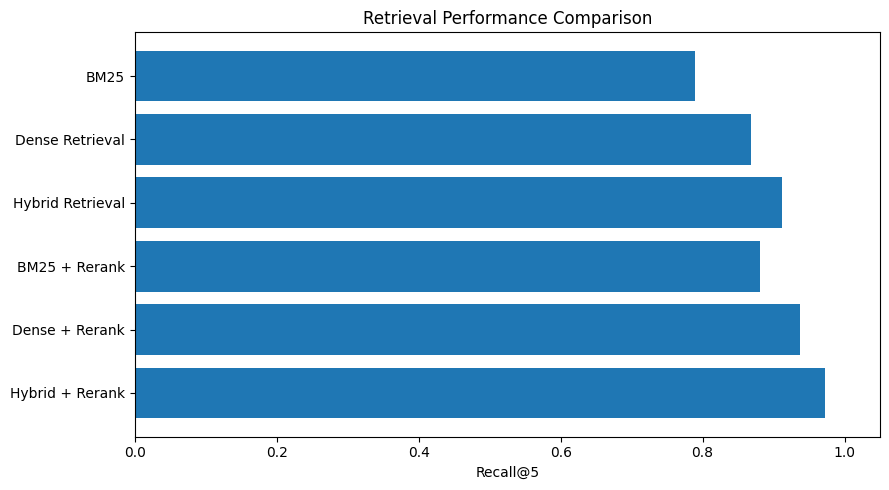

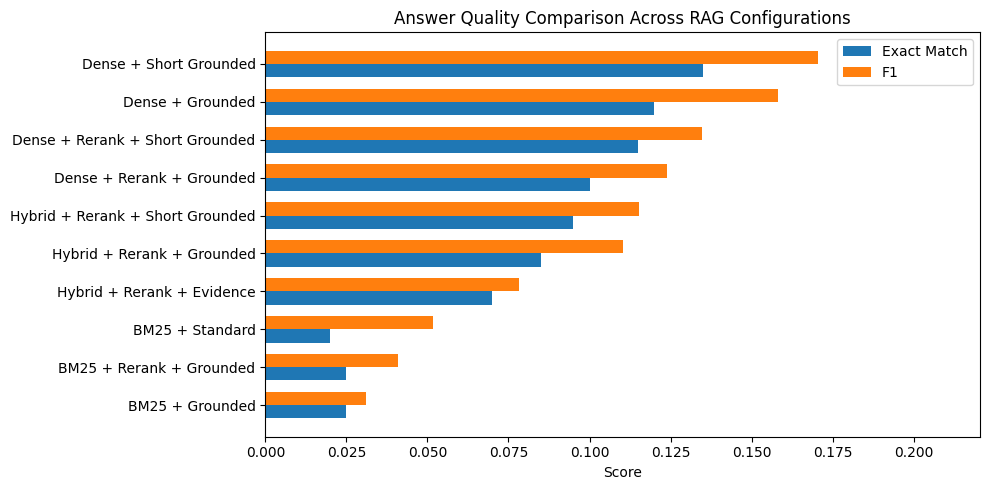

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.barh(retrieval_summary["Method"], retrieval_summary["Recall@5"])
plt.xlabel("Recall@5")
plt.title("Retrieval Performance Comparison")
plt.xlim(0, 1.05)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("retrieval_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

plot_df = answer_quality_summary.copy()
plot_df = plot_df.sort_values("f1", ascending=True)

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.barh(x - width/2, plot_df["em"], height=width, label="Exact Match")
plt.barh(x + width/2, plot_df["f1"], height=width, label="F1")
plt.yticks(x, plot_df["config_name"])
plt.xlabel("Score")
plt.title("Answer Quality Comparison Across RAG Configurations")
plt.xlim(0, max(plot_df["f1"].max(), plot_df["em"].max()) + 0.05)
plt.legend()
plt.tight_layout()
plt.savefig("answer_quality_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Visualization Summary

The retrieval visualization shows that retrieval performance was strong overall, especially after adding reranking. Among the first-stage retrievers, BM25 achieved a Recall@5 of **0.7900**, dense retrieval achieved **0.8685**, and hybrid retrieval achieved **0.9125**. After reranking, dense retrieval improved to **0.9370** and hybrid retrieval improved to **0.9730**, which was the strongest retrieval result.

The answer quality visualization shows a different pattern. The best answer generation configuration was **Dense + Short Grounded**, with an Exact Match score of **0.135** and an F1 score of **0.170**. Short-grounded prompting improved over the original grounded prompt for dense retrieval, dense retrieval with reranking, and hybrid retrieval with reranking. This suggests that output format and concise answer-span extraction were important factors for SQuAD-style evaluation.

However, the gap between retrieval Recall@5 and answer EM/F1 remains large. Even when the system retrieves answer-containing passages, the generator may still fail to extract the exact short answer. This supports the main project finding that retrieval quality and answer generation quality should be evaluated separately.

Together, the visualizations show that reranking and hybrid retrieval are effective for improving evidence access, while short-grounded prompting helps answer formatting. The final answer quality still depends heavily on how well the generation model uses the retrieved evidence.


## 19. Manual Faithfulness Evaluation

Automatic metrics such as Exact Match and F1 measure answer overlap with the reference answer, but they do not directly measure whether the generated answer is supported by the retrieved context. Since the main goal of this project is to study faithfulness in RAG, we also conduct a small manual evaluation.

For this evaluation, we sample generated answers from each RAG configuration and manually check whether each answer is supported by the retrieved top context. Because the updated experiment includes short-grounded configurations, the manual review sample will include these new prompt variants as well.

Each example is labeled using the following scale:

- **1.0**: fully supported by the retrieved context
- **0.5**: partially supported, incomplete, vague, or overly conservative but not hallucinated
- **0.0**: unsupported, incorrect, or hallucinated

This manual review provides a more direct measure of faithfulness than EM or F1 alone.


In [53]:
manual_review_df = (
    rag_results_df
    .groupby("config_name", group_keys=False)
    .apply(lambda x: x.sample(min(4, len(x)), random_state=42))
    .reset_index(drop=True)
)

manual_review_df = manual_review_df[
    [
        "config_name",
        "question",
        "gold_answer",
        "generated_answer",
        "top_context",
        "em",
        "f1"
    ]
].copy()

manual_review_df["faithfulness_label"] = ""
manual_review_df["error_type"] = ""

manual_review_df.to_csv("manual_faithfulness_review_unlabeled.csv", index=False)

manual_review_df

/tmp/ipykernel_632/2206129528.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(4, len(x)), random_state=42))


,config_name,question,gold_answer,generated_answer,top_context,em,f1,faithfulness_label,error_type
0,BM25 + Grounded,What does co-teaching get the students to focu...,learning,Not enough information.,Co-teaching has also become a new trend amongs...,0,0.0,,
1,BM25 + Grounded,Who had established the Russian empire to its ...,Bolshevik leaders,Not enough information.,city became the official capital of the Grand ...,0,0.0,,
2,BM25 + Grounded,The epidemic in Newcastle was the most what in...,devastating loss,Not enough information.,Antiquaries that 47% of the then population of...,0,0.0,,
3,BM25 + Grounded,What service is a VideoGuard UK equipped recei...,Sky,Not enough information.,Provided is a universal Ku band LNB (9.75/10.6...,0,0.0,,
4,BM25 + Rerank + Grounded,What does co-teaching get the students to focu...,learning,Co-teaching,Co-teaching has also become a new trend amongs...,0,0.0,,
5,BM25 + Rerank + Grounded,Who had established the Russian empire to its ...,Bolshevik leaders,Mongol Empire,Bolshevik leaders had effectively reestablishe...,0,0.0,,
6,BM25 + Rerank + Grounded,The epidemic in Newcastle was the most what in...,devastating loss,Not enough information.,Antiquaries that 47% of the then population of...,0,0.0,,
7,BM25 + Rerank + Grounded,What service is a VideoGuard UK equipped recei...,Sky,Not enough information.,Provided is a universal Ku band LNB (9.75/10.6...,0,0.0,,
8,BM25 + Standard,What does co-teaching get the students to focu...,learning,"enrolled 5,847 students in its four graduate d...",Co-teaching has also become a new trend amongs...,0,0.0,,
9,BM25 + Standard,Who had established the Russian empire to its ...,Bolshevik leaders,Ibn al-Athir,city became the official capital of the Grand ...,0,0.0,,


### Manual Labeling Guide

After exporting the sampled results, each example is manually reviewed by comparing the generated answer with the retrieved top context.

The `faithfulness_label` column is filled using:

- `1.0` if the generated answer is clearly supported by the retrieved context.
- `0.5` if the generated answer is partially supported but incomplete, vague, or mixed with unsupported information.
- `0.0` if the generated answer is not supported by the retrieved context or is clearly incorrect.

The `error_type` column is filled using one of the following categories:

- `correct_supported`
- `partially_supported`
- `unsupported_claim`
- `wrong_answer`
- `retrieval_failure`
- `over_refusal`
- `format_mismatch`

In [54]:
manual_labeled_df = pd.read_csv("manual_faithfulness_review_labeled.csv")

manual_labeled_df["faithfulness_label"] = manual_labeled_df["faithfulness_label"].astype(float)

manual_labeled_df.head()

,config_name,question,gold_answer,generated_answer,top_context,em,f1,faithfulness_label,error_type
0,BM25 + Grounded,What does co-teaching get the students to focu...,learning,Not enough information.,Co-teaching has also become a new trend amongs...,0,0.0,0.5,over_refusal
1,BM25 + Grounded,Who had established the Russian empire to its ...,Bolshevik leaders,Not enough information.,city became the official capital of the Grand ...,0,0.0,0.5,retrieval_failure
2,BM25 + Grounded,The epidemic in Newcastle was the most what in...,devastating loss,Not enough information.,Antiquaries that 47% of the then population of...,0,0.0,0.5,over_refusal
3,BM25 + Grounded,What service is a VideoGuard UK equipped recei...,Sky,Not enough information.,Provided is a universal Ku band LNB (9.75/10.6...,0,0.0,0.5,over_refusal
4,BM25 + Rerank + Grounded,What does co-teaching get the students to focu...,learning,Co-teaching,Co-teaching has also become a new trend amongs...,0,0.0,0.0,wrong_answer


In [55]:
faithfulness_summary = (
    manual_labeled_df
    .groupby("config_name")["faithfulness_label"]
    .mean()
    .reset_index()
    .sort_values("faithfulness_label", ascending=False)
)

faithfulness_summary

,config_name,faithfulness_label
5,Dense + Rerank + Short Grounded,0.875
4,Dense + Rerank + Grounded,0.750
9,Hybrid + Rerank + Short Grounded,0.750
8,Hybrid + Rerank + Grounded,0.625
0,BM25 + Grounded,0.500
7,Hybrid + Rerank + Evidence,0.375
6,Dense + Short Grounded,0.375
1,BM25 + Rerank + Grounded,0.250
3,Dense + Grounded,0.250
2,BM25 + Standard,0.000


In [56]:
error_type_summary = (
    manual_labeled_df["error_type"]
    .value_counts()
    .reset_index()
)

error_type_summary.columns = ["error_type", "count"]

error_type_summary

,error_type,count
0,over_refusal,18
1,wrong_answer,9
2,correct_supported,9
3,format_mismatch,2
4,retrieval_failure,1
5,partially_supported,1


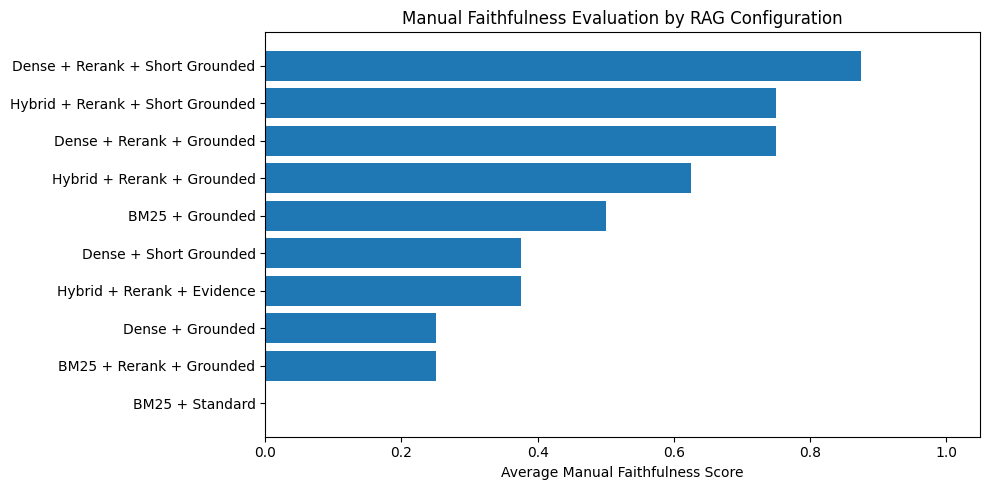

In [57]:
plt.figure(figsize=(10, 5))
plot_df = faithfulness_summary.sort_values("faithfulness_label", ascending=True)

plt.barh(plot_df["config_name"], plot_df["faithfulness_label"])
plt.xlabel("Average Manual Faithfulness Score")
plt.title("Manual Faithfulness Evaluation by RAG Configuration")
plt.xlim(0, 1.05)
plt.tight_layout()
plt.savefig("manual_faithfulness_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Manual Faithfulness Result

The manual faithfulness review provides a more direct evaluation of whether generated answers are supported by the retrieved context. Unlike Exact Match and F1, this evaluation focuses on evidence support rather than exact overlap with the reference answer.

Based on the manually labeled sample, the highest average faithfulness score was achieved by **Dense + Rerank + Short Grounded**, with an average faithfulness score of **0.875**. The next strongest configurations were **Dense + Rerank + Grounded** and **Hybrid + Rerank + Short Grounded**, both with average faithfulness scores of **0.750**.

Overall, the manual results suggest that reranking and short-grounded prompting improved evidence-supported answering in the reviewed sample. This also shows why faithfulness should be evaluated separately from EM and F1: a generated answer can be supported by the retrieved context even if it does not exactly match the gold answer string.


## 20. Error Analysis

To better understand the limitations of the RAG pipeline, we analyze representative failure cases from the generated answers. This is important because aggregate metrics such as Recall@5, Exact Match, F1, and manual faithfulness scores do not fully explain why the system succeeds or fails.

The error analysis focuses on three major questions:

1. Did the retriever find enough relevant evidence?
2. Did the generator correctly use the retrieved evidence?
3. Did the prompt cause formatting or over-refusal problems?

In [58]:
error_type_summary

,error_type,count
0,over_refusal,18
1,wrong_answer,9
2,correct_supported,9
3,format_mismatch,2
4,retrieval_failure,1
5,partially_supported,1


In [59]:
selected_error_cases = manual_labeled_df[
    manual_labeled_df["error_type"].isin([
        "over_refusal",
        "wrong_answer",
        "format_mismatch",
        "retrieval_failure",
        "unsupported_claim",
        "partially_supported"
    ])
].copy()

selected_error_cases = selected_error_cases[
    [
        "config_name",
        "question",
        "gold_answer",
        "generated_answer",
        "top_context",
        "faithfulness_label",
        "error_type"
    ]
]

selected_error_cases.head(10)

,config_name,question,gold_answer,generated_answer,top_context,faithfulness_label,error_type
0,BM25 + Grounded,What does co-teaching get the students to focu...,learning,Not enough information.,Co-teaching has also become a new trend amongs...,0.5,over_refusal
1,BM25 + Grounded,Who had established the Russian empire to its ...,Bolshevik leaders,Not enough information.,city became the official capital of the Grand ...,0.5,retrieval_failure
2,BM25 + Grounded,The epidemic in Newcastle was the most what in...,devastating loss,Not enough information.,Antiquaries that 47% of the then population of...,0.5,over_refusal
3,BM25 + Grounded,What service is a VideoGuard UK equipped recei...,Sky,Not enough information.,Provided is a universal Ku band LNB (9.75/10.6...,0.5,over_refusal
4,BM25 + Rerank + Grounded,What does co-teaching get the students to focu...,learning,Co-teaching,Co-teaching has also become a new trend amongs...,0.0,wrong_answer
5,BM25 + Rerank + Grounded,Who had established the Russian empire to its ...,Bolshevik leaders,Mongol Empire,Bolshevik leaders had effectively reestablishe...,0.0,wrong_answer
6,BM25 + Rerank + Grounded,The epidemic in Newcastle was the most what in...,devastating loss,Not enough information.,Antiquaries that 47% of the then population of...,0.5,over_refusal
7,BM25 + Rerank + Grounded,What service is a VideoGuard UK equipped recei...,Sky,Not enough information.,Provided is a universal Ku band LNB (9.75/10.6...,0.5,over_refusal
8,BM25 + Standard,What does co-teaching get the students to focu...,learning,"enrolled 5,847 students in its four graduate d...",Co-teaching has also become a new trend amongs...,0.0,wrong_answer
9,BM25 + Standard,Who had established the Russian empire to its ...,Bolshevik leaders,Ibn al-Athir,city became the official capital of the Grand ...,0.0,wrong_answer


In [60]:
representative_errors = (
    selected_error_cases
    .groupby("error_type", group_keys=False)
    .apply(lambda x: x.head(1))
    .reset_index(drop=True)
)

representative_errors

/tmp/ipykernel_632/472376754.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.head(1))


,config_name,question,gold_answer,generated_answer,top_context,faithfulness_label,error_type
0,Hybrid + Rerank + Evidence,Who had established the Russian empire to its ...,Bolshevik leaders,3,Bolshevik leaders had effectively reestablishe...,0.0,format_mismatch
1,BM25 + Grounded,What does co-teaching get the students to focu...,learning,Not enough information.,Co-teaching has also become a new trend amongs...,0.5,over_refusal
2,Dense + Short Grounded,Who had established the Russian empire to its ...,Bolshevik leaders,Bolshevik leaders had effectively reestablishe...,Bolshevik leaders had effectively reestablishe...,0.5,partially_supported
3,BM25 + Grounded,Who had established the Russian empire to its ...,Bolshevik leaders,Not enough information.,city became the official capital of the Grand ...,0.5,retrieval_failure
4,BM25 + Rerank + Grounded,What does co-teaching get the students to focu...,learning,Co-teaching,Co-teaching has also become a new trend amongs...,0.0,wrong_answer


In [61]:
representative_errors.to_csv("representative_error_cases.csv", index=False)
selected_error_cases.to_csv("selected_error_cases.csv", index=False)

In [62]:
for idx, row in representative_errors.iterrows():
    print("=" * 100)
    print("Error type:", row["error_type"])
    print("Config:", row["config_name"])
    print("Question:", row["question"])
    print("Gold answer:", row["gold_answer"])
    print("Generated answer:", row["generated_answer"])
    print("Faithfulness label:", row["faithfulness_label"])
    print("Top context:", row["top_context"][:700])

Error type: format_mismatch
Config: Hybrid + Rerank + Evidence
Question: Who had established the Russian empire to its former glory prior to 1921?
Gold answer: Bolshevik leaders
Generated answer: 3
Faithfulness label: 0.0
Top context: Bolshevik leaders had effectively reestablished a polity with roughly the same extent as that empire by 1921, however with an internationalist ideology: Lenin in particular asserted the right to limited self-determination for national minorities within the new territory. Beginning in 1923, the policy of "Indigenization" [korenizatsiia] was intended to support non-Russians develop their national cultures within a socialist framework. Never formally revoked, it stopped being implemented after 1932. After World War II, the Soviet Union installed socialist regimes modeled on those it had installed in 1919–20 in the old Tsarist Empire in areas its forces occupied in Eastern Europe. The Soviet Uni
Error type: over_refusal
Config: BM25 + Grounded
Question: What 

### Error Analysis Summary

The error analysis explains why strong retrieval and higher faithfulness scores did not always translate into high EM and F1. The most common error type was **over-refusal**, which occurred 18 times in the manually reviewed sample. In these cases, the model responded with “Not enough information” even though the retrieved context often contained enough evidence to answer the question. This suggests that grounded prompting can reduce hallucination, but it may also make the generator overly conservative.

The second most common issue was **wrong answer generation**, which occurred 9 times. These cases show that relevant retrieval is not enough by itself: the generator still has to identify the correct entity, phrase, or span from the retrieved passage. For SQuAD-style evaluation, this is especially important because the expected answer is usually short and specific.

The **evidence-based prompt** also produced some **format mismatch** errors. Since this prompt asked the model to provide both an answer and supporting evidence, the output sometimes contained passage references or extra formatting instead of a direct short answer. This lowered automatic EM and F1 even when the retrieved evidence was useful.

A small number of errors were caused by **retrieval failure**, where the top retrieved context did not contain enough information to answer the question. These cases show that although Hybrid + Rerank achieved strong Recall@5 overall, retrieval was not perfect for every individual example.

Overall, the error analysis shows that the main remaining issues are not only about finding relevant passages, but also about making the generator use them correctly. This supports the broader conclusion that RAG faithfulness should be evaluated at both the retrieval stage and the generation stage.

## 21. Conclusion and Future Work

This project built a simple Retrieval-Augmented Generation (RAG) question answering system and evaluated how retrieval, reranking, and prompting choices affect answer quality and faithfulness. The system used a shuffled subset of 2,000 SQuAD validation examples as the document collection. It compared BM25 sparse retrieval, dense retrieval, hybrid retrieval, cross-encoder reranking, standard prompting, grounded prompting, evidence-based prompting, and short-grounded prompting.

The retrieval results show that retrieval design has a clear effect on access to answer-supporting evidence. Among first-stage retrievers, **Hybrid Retrieval** performed best, with a Recall@5 of **0.9125**, followed by **Dense Retrieval** at **0.8685** and **BM25** at **0.7900**. After adding cross-encoder reranking, performance improved further. The strongest retrieval setting was **Hybrid + Rerank**, which achieved a Recall@5 of **0.9730**. This suggests that combining sparse and dense retrieval creates a stronger candidate pool, and reranking helps select better final passages.

The answer generation results show a different pattern. Although retrieval performance was high, the final generated answers still had much lower Exact Match and F1 scores. The best automatic answer quality came from **Dense + Short Grounded**, with an Exact Match score of **0.135** and an F1 score of **0.170**. Short-grounded prompting improved over regular grounded prompting, which suggests that output format and concise answer-span extraction matter for SQuAD-style evaluation. However, the gap between retrieval Recall@5 and answer EM/F1 remained large, showing that strong retrieval alone does not guarantee strong final answers.

The oracle-context experiment helped separate retrieval limitations from generation limitations. When the model was given the gold context directly, **Oracle Context + Short Grounded** achieved an Exact Match score of **0.695** and an F1 score of **0.831**. This was much higher than the normal RAG setting. This result suggests that the generator can extract correct answers when the right context is clearly provided, but full RAG performance is limited by the combined effects of retrieval, ranking, context selection, prompt length, and prompt construction.

The manual faithfulness review provides another important perspective. The highest average faithfulness score in the reviewed sample came from **Dense + Rerank + Short Grounded**, with a score of **0.875**. This shows that automatic EM/F1 and manual faithfulness do not always tell the same story. Some answers may be supported by the retrieved evidence but still fail to exactly match the gold answer string. At the same time, the error analysis showed that over-refusal was common: the model sometimes answered “Not enough information” even when the retrieved context contained enough evidence.

Overall, the main findings are:

1. **Hybrid retrieval performed best among first-stage retrieval methods.**
2. **Cross-encoder reranking improved Recall@5 and produced the strongest retrieval configuration.**
3. **Short-grounded prompting improved answer quality by encouraging concise answer spans.**
4. **Strong retrieval did not automatically lead to strong generated answers.**
5. **Oracle-context results show that context selection and prompt construction are major bottlenecks.**
6. **Manual faithfulness review is necessary because EM and F1 do not fully measure evidence support.**

There are several limitations. First, the project used SQuAD, where many answers are short spans. This makes Exact Match and F1 strict and may penalize answers that are semantically reasonable but formatted differently from the reference answer. Second, the generator was `google/flan-t5-base`, which is lightweight and practical for Colab but less capable than larger instruction-tuned models. Third, the manual faithfulness review was based on a small sample, so it should be interpreted as qualitative support rather than a full-scale human evaluation. Finally, the hybrid retrieval method was still relatively simple and could be improved with better score normalization or learned fusion.

Future work could improve the system in several ways. A stronger generator could be used to test whether final answer quality improves when retrieval is already strong. The prompt construction process could also be improved to prioritize the most relevant passage and reduce truncation effects. Manual faithfulness evaluation could be expanded to more examples and multiple annotators. Finally, the system could be tested on more realistic open-domain or long-document datasets, where hallucination and unsupported generation are more challenging.